<a href="https://colab.research.google.com/github/yiding2022/DAAI/blob/main/Topic_Modeling_and_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topic Modeling

In [1]:
import pandas as pd

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

# Extract the file name
file_name = list(uploaded.keys())[0]

# Load the file into a Pandas DataFrame
df = pd.read_csv(file_name)

In [2]:
url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/reuters_headlines.csv"
df = pd.read_csv(url)

In [3]:
# Remove the irrelevant columns, and take a sample of 1000 rows
df = df.drop(columns=['Headlines', 'Time'], axis=1).sample(1000)
df

,Description
32601,Goldman Sachs Group Inc Chief Executive Lloyd ...
32750,Amazon.com Inc is making a push for merchants ...
4497,U.S. Energy Secretary Dan Brouillette on Frida...
20197,A trial in which a California man alleged his ...
20301,French prosecutors have opened a preliminary i...
...,...
18496,United Technologies Corp said on Wednesday sai...
24967,Volkswagen posted forecast-beating third quar...
26204,SandRidge Energy Inc said on Friday board mem...
24060,The U.S. Environmental Protection Agency (EPA)...


##### Remove punctuation/lower casing

In [ ]:
# Load the regular expression library
import re

# Remove punctuation
df['Description_processed'] = \
df['Description'].map(lambda x: re.sub('[,\.!?]', '', x))

# Convert the titles to lowercase
df['Description_processed'] = \
df['Description_processed'].map(lambda x: x.lower())

df


,Description,Description_processed
18721,Netflix Inc gave a weak forecast on Tuesday th...,netflix inc gave a weak forecast on tuesday th...
9741,Stronger worker and environmental protections ...,stronger worker and environmental protections ...
970,Cerberus wants Commerzbank to cut far more th...,cerberus wants commerzbank to cut far more th...
14065,Citigroup Inc. raised its minimum wage to $15...,citigroup inc raised its minimum wage to $15 ...
6326,"Vehicle sales in China, the world's biggest ca...",vehicle sales in china the world's biggest car...
...,...,...
1687,Nestle is exploring a potential sale of part ...,nestle is exploring a potential sale of part ...
10057,U.S. stocks sold off for a third consecutive s...,us stocks sold off for a third consecutive ses...
12674,"Tesco boss Dave Lewis, credited with saving B...",tesco boss dave lewis credited with saving br...
25917,Renault will introduce hybrid versions of its...,renault will introduce hybrid versions of its...


#### Build cloud word

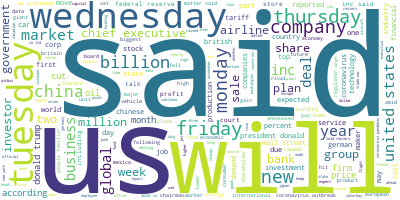

In [ ]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(df['Description_processed'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

#### Prepare text for LDA analysis (topic modeling)

In [ ]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# NLTK Stop words. Define your own stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use','said'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]


data = df.Description_processed.values.tolist()
data_words = list(sent_to_words(data))

# remove stop words
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

['netflix', 'inc', 'gave', 'weak', 'forecast', 'tuesday', 'unnerved', 'investors', 'walt', 'disney', 'co', 'others', 'prepare', 'escalate', 'hollywood', 'streaming', 'video', 'wars', 'although', 'company', 'quarterly', 'results', 'beat', 'wall', 'street', 'targets']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ivydi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import gensim.corpora as corpora

# Create Dictionary: creates a Dictionary object from data_words.
# This object maps each unique token to a unique integer ID.
# The mapping helps in converting textual data into a numerical form that can be processed by algorithms.
id2word = corpora.Dictionary(data_words)

# Create Corpus
texts = data_words

# Term Document Frequency: This part of the code converts each document in texts into a bag-of-words (BoW) format
# using the dictionary id2word created earlier. doc2bow stands for "document to bag-of-words". For each document (or text) in texts,
# it creates a list of tuples where each tuple is (token_id, token_count) representing the unique ID of the token and its frequency in the document.
# This step transforms the textual data into a numerical form that can be used for further analysis, like topic modeling.
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1)]


#### LDA modeling

In [ ]:
from pprint import pprint

# number of topics
num_topics = 5

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)

# Print the Keyword in the 5 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

# interpret the topics below according to the keywords

[(0,
  '0.014*"us" + 0.008*"monday" + 0.007*"wednesday" + 0.006*"trade" + '
  '0.006*"inc" + 0.006*"year" + 0.006*"chief" + 0.006*"group" + '
  '0.005*"executive" + 0.005*"billion"'),
 (1,
  '0.019*"us" + 0.006*"inc" + 0.006*"friday" + 0.005*"bank" + '
  '0.004*"wednesday" + 0.004*"tuesday" + 0.004*"executive" + 0.004*"co" + '
  '0.004*"billion" + 0.004*"economic"'),
 (2,
  '0.010*"us" + 0.007*"inc" + 0.007*"tuesday" + 0.006*"monday" + 0.005*"trade" '
  '+ 0.005*"wednesday" + 0.005*"coronavirus" + 0.005*"market" + 0.004*"new" + '
  '0.004*"billion"'),
 (3,
  '0.013*"us" + 0.007*"inc" + 0.007*"thursday" + 0.005*"year" + '
  '0.005*"tuesday" + 0.005*"wednesday" + 0.005*"new" + 0.004*"coronavirus" + '
  '0.004*"monday" + 0.004*"federal"'),
 (4,
  '0.016*"us" + 0.011*"china" + 0.010*"trade" + 0.008*"inc" + 0.008*"friday" + '
  '0.007*"thursday" + 0.006*"billion" + 0.005*"trump" + 0.005*"president" + '
  '0.005*"new"')]


Sentiment analysis

In [ ]:
df = pd.read_csv('reuters_headlines.csv')

In [ ]:
# Remove the columns
df = df.drop(columns=['Headlines', 'Time'], axis=1).sample(1000)

# Print out the first rows of papers
df

,Description
23935,"(This Nov. 26 story, corrects date and clarifi..."
11792,"Albemarle Corp , the world's largest lithium p..."
19308,Massachusetts gaming regulators on Tuesday rel...
20817,A federal judge in Manhattan on Tuesday dismis...
25799,Sweden's Swedbank said on Thursday that there...
...,...
4286,U.S. crude oil stockpiles rose by 19 million b...
31269,German luxury carmaker BMW expects the pace o...
18815,Gulfstream Aerospace and Bombardier are trotti...
18700,"Terry Gou, chairman of Apple supplier Foxconn,..."


In [ ]:
# use VADER method to assess the sentiment of the descriptions
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ivydi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Create empty lists to store the sentiment scores
compound_scores = []
positive_scores = []
negative_scores = []
neutral_scores = []

# Iterate over each record in the dataframe
for index, row in df.iterrows():
    # Get the description text
    description = row['Description']

    # Analyze the sentiment using VADER
    sentiment_scores = sia.polarity_scores(description)

    # Append the sentiment scores to the respective lists
    compound_scores.append(sentiment_scores['compound'])
    positive_scores.append(sentiment_scores['pos'])
    negative_scores.append(sentiment_scores['neg'])
    neutral_scores.append(sentiment_scores['neu'])

# Add the sentiment scores as new columns in the dataframe
df['Compound_Score'] = compound_scores
df['Positive_Score'] = positive_scores
df['Negative_Score'] = negative_scores
df['Neutral_Score'] = neutral_scores

# Print the updated dataframe
df


,Description,Compound_Score,Positive_Score,Negative_Score,Neutral_Score
23935,"(This Nov. 26 story, corrects date and clarifi...",-0.0516,0.068,0.075,0.857
11792,"Albemarle Corp , the world's largest lithium p...",0.4588,0.124,0.051,0.825
19308,Massachusetts gaming regulators on Tuesday rel...,0.0000,0.000,0.000,1.000
20817,A federal judge in Manhattan on Tuesday dismis...,-0.8860,0.092,0.315,0.592
25799,Sweden's Swedbank said on Thursday that there...,-0.4215,0.064,0.146,0.789
...,...,...,...,...,...
4286,U.S. crude oil stockpiles rose by 19 million b...,-0.2023,0.101,0.119,0.780
31269,German luxury carmaker BMW expects the pace o...,0.3818,0.073,0.000,0.927
18815,Gulfstream Aerospace and Bombardier are trotti...,0.1779,0.052,0.000,0.948
18700,"Terry Gou, chairman of Apple supplier Foxconn,...",-0.4588,0.000,0.114,0.886
